In [16]:
import pandas as pd
import numpy as np

In [17]:
pip install pyodbc sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [18]:
from sqlalchemy import create_engine

### Database Connection Parameters

In [19]:
SERVER = 'localhost\\SQLEXPRESS' 
DATABASE = 'HR_Analytics' 

In [20]:
connection_string = f"mssql+pyodbc://@{SERVER}/{DATABASE}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(connection_string)

In [21]:
query = "SELECT * FROM HR_employee_attrition;"
df = pd.read_sql(query, engine)

In [22]:
print(f"Dataset Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded Successfully: 1470 rows, 32 columns


In [23]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,3,4,0,17,3,2,9,6,0,8


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [27]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [29]:
df[df.duplicated()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [31]:
df = df.rename(columns={"BusinessTravel":"Business_Travel","DailyRate":"Daily_Rate","DistanceFromHome":"Distance_From_Home","EducationField":"Education_Field",
                        "EmployeeNumber":"Employee_Number","EnvironmentSatisfaction":"Environment_Satisfaction","HourlyRate":"Hourly_Rate",
                        "JobInvolvement":"Job_Involvement","JobLevel":"Job_Level","JobRole":"Job_Role","JobSatisfaction": "Job_Satisfaction",
                        "MaritalStatus":"Marital_Status","MonthlyIncome":"Monthly_Income","MonthlyRate":"Monthly_Rate","NumCompaniesWorked":"Num_Companies_Worked",
                       "OverTime":"Over_Time","PercentSalaryHike":"Percent_Salary_Hike","PerformanceRating":"Performance_Rating",
                       "RelationshipSatisfaction":"Relationship_Satisfaction","StockOptionLevel":"Stock_Option_Level","TotalWorkingYears":"Total_Working_Years",
                       "TrainingTimesLastYear":"Training_Times_Last_Year","WorkLifeBalance":"Work_Life_Balance","YearsAtCompany":"Years_At_Company",
                       "YearsInCurrentRole":"Years_In_Current_Role","YearsSinceLastPromotion":"Years_Since_Last_Promotion",
                        "YearsWithCurrManager":"Years_With_Curr_Manager",})

In [32]:
df.columns

Index(['Age', 'Attrition', 'Business_Travel', 'Daily_Rate', 'Department',
       'Distance_From_Home', 'Education', 'Education_Field', 'Employee_Number',
       'Environment_Satisfaction', 'Gender', 'Hourly_Rate', 'Job_Involvement',
       'Job_Level', 'Job_Role', 'Job_Satisfaction', 'Marital_Status',
       'Monthly_Income', 'Monthly_Rate', 'Num_Companies_Worked', 'Over_Time',
       'Percent_Salary_Hike', 'Performance_Rating',
       'Relationship_Satisfaction', 'Stock_Option_Level',
       'Total_Working_Years', 'Training_Times_Last_Year', 'Work_Life_Balance',
       'Years_At_Company', 'Years_In_Current_Role',
       'Years_Since_Last_Promotion', 'Years_With_Curr_Manager'],
      dtype='object')

### Feature Preprocessing & Encoding

In [15]:
# Define Binary Target

In [33]:
df['Target'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)  #(1 = Attrition/Leaver, 0 = Active/Stayer)

In [16]:
# Select Relevant Feature Columns

In [34]:
numerical_features = [
    'Age', 'Monthly_Income', 'Distance_From_Home', 'Job_Satisfaction', 
    'Environment_Satisfaction', 'Work_Life_Balance', 'Years_At_Company', 
    'Years_Since_Last_Promotion', 'Total_Working_Years', 'Stock_Option_Level',
    'Percent_Salary_Hike', 'Num_Companies_Worked'
]

In [35]:
categorical_features = ['Over_Time', 'Department', 'Job_Role', 'Business_Travel', 'Marital_Status']

In [17]:
# One-Hot Encoding for Categoricals

In [36]:
df_encoded = pd.get_dummies(df[numerical_features + categorical_features], drop_first=True)

In [37]:
X = df_encoded
y = df['Target']

### Training Machine Learning Model

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [20]:
# Train-Test Split (Stratified to handle target imbalance)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Initialize & Fit Random Forest Model

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=6, 
    random_state=42, 
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [24]:
# Evaluate Model

In [41]:
y_pred_proba_test = rf_model.predict_proba(X_test)[:, 1]

In [42]:
print(f"ROC-AUC Performance Score: {roc_auc_score(y_test, y_pred_proba_test):.3f}")

ROC-AUC Performance Score: 0.767


### Generate Risk Scores

In [43]:
# Generate Probability Scores (Risk Scores) for Full Dataset

In [44]:
df['Risk_Score'] = (rf_model.predict_proba(X)[:, 1] * 100).round(1)

In [29]:
# Segment Into Risk Tiers

In [45]:
df['Risk_Category'] = pd.cut(
    df['Risk_Score'], 
    bins=[-1, 30, 60, 100], 
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

### Extract Top Attrition Drivers & Export Clean File

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Extract & Plot Feature Importances

In [47]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

In [48]:
importances

Monthly_Income              0.138273
Age                         0.105108
Over_Time_Yes               0.094015
Total_Working_Years         0.092510
Years_At_Company            0.080468
Stock_Option_Level          0.064224
Distance_From_Home          0.055912
Num_Companies_Worked        0.052178
Environment_Satisfaction    0.039931
Percent_Salary_Hike         0.034257
dtype: float64

C:\Users\Sreejith\AppData\Local\Temp\ipykernel_9836\720216820.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


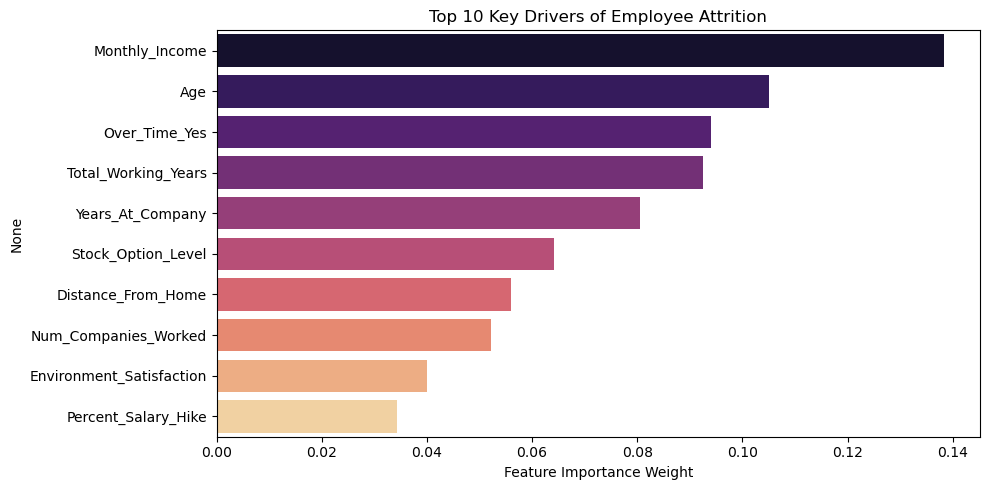

In [49]:
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Top 10 Key Drivers of Employee Attrition')
plt.xlabel('Feature Importance Weight')
plt.tight_layout()
plt.savefig('F:\\Sreejith\\Project\\feature_importance.png')
plt.show()

In [37]:
# Export Processed Dataset to CSV (For Power BI / Repo)

In [50]:
df.to_csv('F:\\Sreejith\\Project\\hr_data_with_risk_scores.csv', index=False)

In [39]:
# Write Processed Table Back to MS SQL

In [51]:
df.to_sql('hr_employee_attrition_processed', engine, if_exists='replace', index=False)
print("Processed dataset with Flight Risk Scores exported to MS SQL & CSV.")

Processed dataset with Flight Risk Scores exported to MS SQL & CSV.
